# Shoreline calibration of the georeferencing

A land–water boundary in the thermal image must fall onto the reference shoreline after georeferencing. Notebook 03 checks one Svalbard frame: `georef_paulr` misses the shoreline by about 100 m there, `processing.project` by about 500 m. Labelled shoreline pixels from **many** coastline passages constrain what is wrong:

| error source | shifts the image | size |
|---|---|---|
| pitch offset `dpitch` | along track | `alt · dpitch` (12 km · 0.5° ≈ 100 m) |
| time offset `dt` | along track | `gs · dt` (230 m/s · 0.5 s ≈ 115 m) |
| roll offset `droll` | across track | `alt · droll` |
| yaw offset `dyaw` | rotates the frame | up to `4.5 km · dyaw` at the edges |

One coast constrains only the component across that coast: the Svalbard frame of notebook 03 flies along the coast (heading 351°, coast at 12° to the track) and therefore sees only across-track errors. Passages at different headings (the outbound and return legs of each flight), coast orientations, altitudes and speeds separate the four. Pitch and timing both move the image along track. They can be separated only through their different dependence on altitude and ground speed, or through a separate time offset for each flight (the VELOX clock may be off differently per flight; HALO-(AC)³ frame times are stored in whole seconds).

**Workflow**

1. find the coastline passages (*events*) of all flights and cache their frames (done once, ~15 min);
2. rate the sky of each event and click shoreline pixels; labels are saved immediately to `shoreline_labels/`;
3. fit corrections to the boresight angles and the timing, and check them with leave-one-flight-out fits.

The reference is the OpenStreetMap coastline (© OpenStreetMap contributors, [ODbL](https://www.openstreetmap.org/copyright)), downloaded on first use (~900 MB). The mainland Norwegian coast in OSM comes from the Kartverket N50 map and is accurate to about 10 m. Elsewhere, check the reference before relying on it. Glacier fronts, sea ice and tidal flats move. Pixels are projected onto the EGM96 geoid (sea level), which lies 30–50 m above or below the WGS84 ellipsoid in the campaign areas.

`georef_paulr` uses the same window of the calibration grid for every channel since this notebook was written. Paul Rothenberg fitted the boresight offsets of all channels with the ground control points of one channel-aligned image. The channel-specific windows used before applied the channel alignment twice (4–5 px for channel 3).

In [5]:
%matplotlib widget
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely
from IPython.display import display
from matplotlib.collections import LineCollection
from scipy import ndimage
from scipy.spatial import cKDTree
from shapely.ops import transform

from velox_tools import shoreline

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 200)

CHANNEL = 1
CACHE = shoreline.default_cache()          # downloads and cached frames (~2 GB)
store = shoreline.LabelStore('shoreline_labels')  # your labels, next to this notebook
print(f'cache: {CACHE}\nlabels: {store.directory.resolve()}')

cache: /projekt_agmwend/home_rad/Joshua/tmp/pyvelox-coastlines
labels: /projekt_agmwend/home_rad/Joshua/pyVELOX/velox_tools/notebooks/shoreline_labels


## 1. Coastline passages

An *event* is a stretch of flight during which at least 1 km of reference shoreline runs through the inner 70 % of the frame, split into parts of at most 60 s. Its frame is the one with the most shoreline in view, and frames 4 and 8 s before and after it are cached as well. The first run searches all flights and reads the frames from the archive: about 2 minutes for the search and 10–15 minutes for the frames, because every HALO-(AC)³ frame decompresses a 3 GB block. Later runs only load the tables.

`crossing_angle` is the angle between track and coast (90°: perpendicular, constrains along-track errors; 0°: parallel, constrains across-track errors). `straightness` is low for islands and bays, which constrain both directions in a single frame.

In [6]:
events = shoreline.find_all_events(cache=CACHE)
shoreline.cache_frames(events, channel=CHANNEL, cache=CACHE)
cached = [(shoreline._frame_dir(CACHE, CHANNEL) / f'{e}.nc').exists() for e in events['event_id']]
events = events[cached].reset_index(drop=True)

summary = events.groupby(['campaign', 'flight'], sort=False).agg(
    events=('event_id', 'size'), headings=('hdg', lambda h: ' '.join(f'{v:.0f}' for v in h[::max(1, len(h) // 6)])))
print(f'{len(events)} events in {summary.shape[0]} flights; flights without events: '
      + ', '.join(f'{c} {rf}' for c, rf in shoreline.flights() if (c, rf) not in summary.index))
summary.T

522 events in 28 flights; flights without events: PERCUSION RF02, PERCUSION RF03, PERCUSION RF04, PERCUSION RF05, PERCUSION RF08, PERCUSION RF10, PERCUSION RF12, PERCUSION RF13, PERCUSION RF14, PERCUSION RF15, PERCUSION RF16, PERCUSION RF17, PERCUSION RF18, PERCUSION RF19, PERCUSION RF21, PERCUSION RF22, PERCUSION RF23


campaign                         HALO-AC3                                                                                                                                                     \
flight                               RF03                      RF04                             RF05                       RF06                        RF07                             RF08   
events                                  8                        19                               15                         38                          19                               22   
headings  325 324 324 154 154 156 154 154  32 33 33 354 180 180 180  347 347 346 168 164 159 162 162  354 9 335 167 168 184 171  348 350 348 278 14 144 146  352 332 331 328 159 333 170 188   

campaign                                                                                                                                ...                  PERCUSION                             \
flight                              RF09                 RF10                        RF11                                         RF12  ...                       RF07    RF09          RF11 RF20   
events                                15                   24                          31                                           11  ...                          7       3             4    1   
headings  347 346 36 349 160 161 161 161  14 15 2 175 175 174  346 348 347 345 13 210 210  348 350 349 349 349 344 343 343 343 342 342  ...  82 82 101 115 116 115 115  5 5 56  90 91 91 209    5   

campaign                                                                                                                                                     
flight                  ECVal_RF01                 ECVal_RF02               ECVal_RF03              ECVal_RF04                ECVal_RF05         ECVal_RF06  
events                          26                         21                       42                      31                        53                 42  
headings  11 10 11 298 142 143 124  13 12 299 297 110 106 106  135 195 194 195 315 314  17 16 18 16 16 288 160  13 12 15 162 161 161 158  1 7 11 21 165 179  

[2 rows x 28 columns]

The 25 shoreline pixels picked in notebook 03 (Svalbard, 2022-04-04 09:03:31) are imported once as the first labels. Their frame lies between the cached ones and is added to the cache.

In [7]:
old_labels = Path('halo-ac3_shoreline_discrepancies.csv')
t03 = pd.Timestamp('2022-04-04T09:03:31')
near = events[(events['time'] - t03).abs() < pd.Timedelta(30, 's')]
if old_labels.exists() and len(near) and not (store.points['time'] == t03).any():
    event = near.iloc[0]
    frames, _ = shoreline.load_event(event['event_id'], CHANNEL, CACHE)
    if np.datetime64(t03) not in frames['time'].values:
        shoreline.add_frames(event['event_id'], [t03], CHANNEL, CACHE)
    for x, y in pd.read_csv(old_labels)[['x', 'y']].to_numpy():
        store.add_point(event, t03, CHANNEL, x, y)
    store.set_flag(event, sky='clear', note='imported from notebook 03')
store.points.groupby(['event_id', 'time']).size().rename('pixels').to_frame()

pixels
event_id             time                       
HALO-AC3_RF03_082512 2022-03-13 08:25:12      43
                     2022-03-13 08:25:20      19
HALO-AC3_RF03_082703 2022-03-13 08:27:03      15
HALO-AC3_RF03_163042 2022-03-13 16:30:42       7
HALO-AC3_RF03_163046 2022-03-13 16:30:46      43
HALO-AC3_RF03_163233 2022-03-13 16:32:33      23
HALO-AC3_RF03_163452 2022-03-13 16:34:52      16
HALO-AC3_RF13_090320 2022-04-04 09:03:31      25

## 2. Label

Choose an event (filter by campaign, flight or status), look through its frames, and rate the sky:

- **clear**: the shoreline is visible along its length;
- **partly cloudy**: parts of it are visible; label only those;
- **cloudy**: no usable shoreline;
- **unusable**: shoreline hidden or displaced for other reasons, e.g. sea ice, a glacier front, no thermal contrast, or a reference that does not match.

Only *clear* and *partly cloudy* events are used in the fit.

**Left-click** shoreline pixels in the left panel, the detector image with flight direction up and starboard on the right. **Right-click** removes the nearest label. With *snap to edge*, a click moves to the strongest brightness-temperature gradient within 2 px. Label wherever the boundary is clear, preferably along all coast orientations in the frame. 10–40 pixels per frame are plenty.

**Scroll** to zoom at the cursor and **drag** with the left button to pan, in either panel. A click that does not move labels, so there is no need to switch tools. The zoom is kept when you step through the frames of an event. Keys, after clicking into the figure: `h` reset the view, `n`/`p` next/previous event, `→`/`←` next/previous frame, `1`–`5` sky rating, `u` undo.

**Suggest edges** adds candidate pixels (yellow): along the reference shoreline, the strongest thermal edge within ±300 m perpendicular to it. They are located by the image alone, but the search follows the reference, so **review them**: right-click wrong ones (cloud edges, sea ice, glacier fronts) or use *Clear suggestions*. Suggestions are stored with `source='suggested'`, and the fit can leave them out (`SOURCES` in section 3). On your 25 Svalbard pixels they agree with the manual picks (median distance from the reference 80 m, compared with 74 m for the manual picks).

The right panel shows the georeferenced frame with the reference shoreline (orange), your labels (cyan: manual, yellow: suggested) and their offsets from the shoreline (magenta). Label in the left panel so that the reference line does not guide your eye. *Reference in image* draws the shoreline into the detector image. Use it only to identify which edge is the coast. After a fit (section 3), *apply fitted correction* shows the corrected geometry.

Aim for **at least two labelled events per flight, on different legs (headings)**. Also cover as many coast orientations, altitudes and ground speeds as possible.

In [28]:
import time


class ShorelineLabeler:
    # Browse events, rate the sky, and click shoreline pixels; everything is saved in `store`.

    STATUS = ['all', 'unrated', 'usable', 'usable, few points', 'labelled']
    MARK = {'unrated': '·', 'clear': '○', 'partly cloudy': '◐', 'cloudy': '☁', 'unusable': '✗'}

    def __init__(self, events, store, channel=CHANNEL, cache=CACHE, min_points=5):
        self.events, self.store = events.reset_index(drop=True), store
        self.channel, self.cache, self.min_points = channel, cache, min_points
        self.correction = None
        self.i = None           # current event (row of self.events)
        self.frames = None      # its cached frames
        self._geo = {}          # (frame time, corrected) -> (east, north) of every pixel, km
        self._tree = {}         # same key -> KD-tree of the pixel positions
        self._quiet = False     # True while widgets are set programmatically

        layout = lambda w: widgets.Layout(width=w)
        self.w_campaign = widgets.Dropdown(options=['all', *sorted(self.events['campaign'].unique())],
                                           description='campaign', layout=layout('230px'))
        self.w_flight = widgets.Dropdown(options=['all'], description='flight', layout=layout('190px'))
        self.w_status = widgets.Dropdown(options=self.STATUS, description='show', layout=layout('230px'))
        self.w_event = widgets.Dropdown(layout=layout('610px'))
        self.w_prev = widgets.Button(description='◀', layout=layout('40px'), tooltip='previous event (p)')
        self.w_next = widgets.Button(description='▶', layout=layout('40px'), tooltip='next event (n)')
        self.w_frame = widgets.SelectionSlider(options=[('0 s', 0)], description='frame', continuous_update=False,
                                               layout=layout('360px'))
        self.w_sky = widgets.ToggleButtons(options=shoreline.SKY, style={'button_width': '100px'})
        self.w_note = widgets.Text(placeholder='note, e.g. sea ice, glacier front', continuous_update=False,
                                   layout=layout('430px'))
        self.w_snap = widgets.Checkbox(value=True, description='snap to edge (±2 px)', indent=False)
        self.w_ref = widgets.Checkbox(value=False, description='reference in image', indent=False)
        self.w_corr = widgets.Checkbox(value=False, description='apply fitted correction', indent=False,
                                       disabled=True)
        self.w_undo = widgets.Button(description='Undo (u)', layout=layout('90px'))
        self.w_clear = widgets.Button(description='Clear frame', layout=layout('100px'))
        self.w_suggest = widgets.Button(description='Suggest edges', layout=layout('120px'), button_style='info')
        self.w_unsuggest = widgets.Button(description='Clear suggestions', layout=layout('140px'))
        self.w_info = widgets.HTML()

        with plt.ioff():
            self.fig, (self.ax_img, self.ax_map) = plt.subplots(1, 2, figsize=(11.5, 5.4), layout='constrained')
        self.fig.canvas.header_visible = False
        self.fig.canvas.toolbar_position = 'left'
        self.fig.canvas.capture_scroll = True  # the wheel zooms the figure instead of scrolling the notebook
        manager = getattr(self.fig.canvas, 'manager', None)
        if getattr(manager, 'key_press_handler_id', None) is not None:
            # matplotlib's default keys clash with ours ('p' switches on pan mode, arrows step the view history)
            self.fig.canvas.mpl_disconnect(manager.key_press_handler_id)
        self._drag = None       # left-button press: where, and whether it has moved (pan) or not (label)
        self._last_draw = 0.0
        for name, handler in [('button_press_event', self.on_press), ('motion_notify_event', self.on_motion),
                              ('button_release_event', self.on_release), ('scroll_event', self.on_scroll),
                              ('key_press_event', self.on_key)]:
            self.fig.canvas.mpl_connect(name, handler)

        self.w_campaign.observe(lambda _: self.refilter(), 'value')
        self.w_flight.observe(lambda _: self.refilter(keep_flight=True), 'value')
        self.w_status.observe(lambda _: self.refilter(keep_flight=True), 'value')
        self.w_event.observe(lambda c: None if self._quiet or c['new'] is None else self.load(c['new']), 'value')
        self.w_prev.on_click(lambda _: self.step_event(-1))
        self.w_next.on_click(lambda _: self.step_event(1))
        self.w_frame.observe(lambda _: None if self._quiet else self.show_frame(keep_view=True), 'value')
        self.w_sky.observe(self.on_sky, 'value')
        self.w_note.observe(self.on_note, 'value')
        self.w_ref.observe(lambda _: self.show_frame(keep_view=True), 'value')
        self.w_corr.observe(lambda _: self.show_frame(keep_view=True), 'value')
        self.w_undo.on_click(lambda _: self.undo())
        self.w_clear.on_click(lambda _: self.clear())
        self.w_suggest.on_click(lambda _: self.suggest())
        self.w_unsuggest.on_click(lambda _: self.clear(source='suggested'))

        self.ui = widgets.VBox([
            widgets.HBox([self.w_campaign, self.w_flight, self.w_status]),
            widgets.HBox([self.w_prev, self.w_event, self.w_next]),
            widgets.HBox([self.w_sky]),
            widgets.HBox([self.w_frame, self.w_note]),
            self.fig.canvas,
            widgets.HBox([self.w_suggest, self.w_unsuggest, self.w_undo, self.w_clear]),
            widgets.HBox([self.w_snap, self.w_ref, self.w_corr]),
            self.w_info,
        ])
        self.refilter()

    # -- event list ---------------------------------------------------------
    def points_in_event(self, event_id):
        p = self.store.points
        return int(((p['event_id'] == event_id) & (p['channel'] == self.channel)).sum())

    def status(self, i):
        e = self.events.loc[i]
        sky, n = self.store.sky(e['event_id']), self.points_in_event(e['event_id'])
        usable = sky in ('clear', 'partly cloudy')
        return sky, n, usable

    def label(self, i):
        e = self.events.loc[i]
        sky, n, usable = self.status(i)
        mark = '✔' if usable and n >= self.min_points else self.MARK[sky]
        return (f"{mark} {e['flight']:>10}  {e['time']:%Y-%m-%d %H:%M:%S}  hdg {e['hdg']:3.0f}°  "
                f"{e['alt'] / 1e3:4.1f} km  coast ∠{e['crossing_angle']:2.0f}°  {e['coast_km']:4.1f} km"
                + (f'  [{n} px]' if n else ''))

    def refilter(self, keep_flight=False):
        ev = self.events
        if self.w_campaign.value != 'all':
            ev = ev[ev['campaign'] == self.w_campaign.value]
        if not keep_flight:
            self._quiet = True
            self.w_flight.options = ['all', *dict.fromkeys(ev['flight'])]
            self.w_flight.value = 'all'
            self._quiet = False
        if self.w_flight.value != 'all':
            ev = ev[ev['flight'] == self.w_flight.value]
        status = self.w_status.value
        if status != 'all':
            keep = []
            for i in ev.index:
                sky, n, usable = self.status(i)
                keep.append({'unrated': sky == 'unrated', 'usable': usable,
                             'usable, few points': usable and n < self.min_points,
                             'labelled': usable and n >= self.min_points}[status])
            ev = ev[keep]
        self._quiet = True
        self.w_event.options = [(self.label(i), i) for i in ev.index]
        if self.i in ev.index:
            self.w_event.value = self.i
        self._quiet = False
        if len(ev) == 0:
            self.w_info.value = '<i>No events with this filter.</i>'
        elif self.i not in ev.index:
            self.load(ev.index[0])  # setting the options has already selected it

    def relabel(self):
        # refresh the dropdown text of the current event (after a label or rating changed)
        if self.i not in [i for _, i in self.w_event.options]:
            return
        self._quiet = True
        self.w_event.options = [(self.label(i), i) if i == self.i else (text, i) for text, i in self.w_event.options]
        self.w_event.value = self.i
        self._quiet = False

    def step_event(self, step):
        indices = [i for _, i in self.w_event.options]
        if indices:
            k = indices.index(self.i) if self.i in indices else -step
            self.w_event.value = indices[(k + step) % len(indices)]

    # -- loading and drawing ------------------------------------------------
    def load(self, i):
        self.i = i
        if self.w_event.value != i:
            self._quiet = True
            self.w_event.value = i
            self._quiet = False
        e = self.events.loc[i]
        self.frames, coast = shoreline.load_event(e['event_id'], self.channel, self.cache)
        self.to_local = shoreline._local(e['lat'], e['lon'])
        self.coast = transform(lambda x, y: tuple(np.asarray(v) / 1e3 for v in self.to_local(x, y)), coast)
        self._geo, self._tree = {}, {}
        times = self.frames['time'].values
        offsets = (times - np.datetime64(e['time'])) / np.timedelta64(1, 's')
        counts = [len(self.store.frame_points(e['event_id'], t, self.channel)) for t in times]
        self._quiet = True
        self.w_frame.options = [(f'{o:+.0f} s' + (f' ({n})' if n else ''), k)
                                for k, (o, n) in enumerate(zip(offsets, counts))]
        self.w_frame.value = int(np.argmax(counts)) if max(counts) else int(np.argmin(np.abs(offsets)))
        self.w_sky.value = self.store.sky(e['event_id'])
        self.w_note.value = self.store.note(e['event_id'])
        self._quiet = False
        self.show_frame(keep_view=False)

    @property
    def event(self):
        return self.events.loc[self.i]

    @property
    def time(self):
        return self.frames['time'].values[self.w_frame.value]

    def geo(self):
        # east/north (km, from the aircraft at the event time) of every pixel of the current frame
        corrected = bool(self.w_corr.value and self.correction)
        key = (self.time, corrected)
        if key not in self._geo:
            g = shoreline.georef_corrected(self.time, self.channel, self.correction if corrected else None)
            east, north = self.to_local(g['lon'].values, g['lat'].values)
            self._geo[key] = (east / 1e3, north / 1e3)
        return self._geo[key]

    def tree(self):
        key = (self.time, bool(self.w_corr.value and self.correction))
        if key not in self._tree:
            east, north = self.geo()
            self._tree[key] = cKDTree(np.column_stack([east.ravel(), north.ravel()]))
        return self._tree[key]

    def show_frame(self, keep_view=True):
        if self.frames is None:
            return
        limits = (self.ax_img.get_xlim(), self.ax_img.get_ylim(), self.ax_map.get_xlim(), self.ax_map.get_ylim())
        bt = self.frames['BT_2D'].values[self.w_frame.value]
        self.bt = bt
        finite = bt[np.isfinite(bt)]
        vmin, vmax = np.percentile(finite, [5, 95]) if finite.size else (0, 1)
        self.gradient = np.hypot(*np.gradient(ndimage.gaussian_filter(np.nan_to_num(bt, nan=np.nanmean(bt)), 1)))
        east, north = self.geo()

        ax = self.ax_img
        ax.clear()
        ax.imshow(bt.T, origin='lower', cmap='gray', vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.set_xlim(634.5, -0.5)  # starboard (x = 0) on the right
        ax.set(xlabel='x pixel', ylabel='y pixel (flight direction ↑)', title='detector image: click shoreline')
        if self.w_ref.value:
            self.draw_reference_in_image()
        self.img_points = ax.scatter([], [], s=40, facecolors='none', linewidths=1.3)

        ax = self.ax_map
        ax.clear()
        ax.pcolormesh(self.corners(east[::2, ::2]), self.corners(north[::2, ::2]), bt[::2, ::2], shading='flat',
                      cmap='viridis', vmin=vmin, vmax=vmax, rasterized=True)
        for part in shapely.get_parts(self.coast):
            if part.geom_type in ('LineString', 'LinearRing'):
                ax.plot(*part.xy, color='#eb6834', lw=1)
        nav = self.event
        ax.plot(0, 0, marker=(3, 0, -nav['hdg']), color='#eb6834', ms=9, ls='none')
        ax.set(aspect='equal', xlabel='east (km)', ylabel='north (km)',
               xlim=(east.min(), east.max()), ylim=(north.min(), north.max()),
               title='georeferenced' + (' (corrected)' if self.w_corr.value and self.correction else ''))
        self.map_points = ax.scatter([], [], s=18, zorder=3)
        self.map_offsets = LineCollection([], colors='magenta', linewidths=1.5, zorder=4)
        ax.add_collection(self.map_offsets)
        if keep_view and limits[0] != (0.0, 1.0):
            self.ax_img.set_xlim(limits[0]); self.ax_img.set_ylim(limits[1])
            self.ax_map.set_xlim(limits[2]); self.ax_map.set_ylim(limits[3])
        self.update_points()

    @staticmethod
    def corners(centres):
        # pixel corners of a rotated grid of pixel centres, extrapolating the outer half pixel
        p = np.pad(centres, 1, mode='edge')
        p[0, 1:-1], p[-1, 1:-1] = 2 * centres[0] - centres[1], 2 * centres[-1] - centres[-2]
        p[:, 0], p[:, -1] = 2 * p[:, 1] - p[:, 2], 2 * p[:, -2] - p[:, -3]
        return (p[:-1, :-1] + p[1:, :-1] + p[:-1, 1:] + p[1:, 1:]) / 4

    def draw_reference_in_image(self):
        # shoreline drawn at the nearest pixel centres (only where it lies within the frame)
        east, north = self.geo()
        pixel = np.hypot(east[1, 253] - east[0, 253], north[1, 253] - north[0, 253])
        for part in shapely.get_parts(shapely.segmentize(self.coast, pixel / 2)):
            if part.geom_type not in ('LineString', 'LinearRing'):
                continue
            dist, index = self.tree().query(np.asarray(part.coords)[:, :2])
            x, y = np.divmod(index, east.shape[1])
            inside = dist < pixel
            self.ax_img.plot(np.where(inside, x, np.nan), np.where(inside, y, np.nan), color='#eb6834',
                             lw=0.9, ls=(0, (3, 2)), alpha=0.8)

    def frame_labels(self):
        p = self.store.points
        e = self.event
        return p[(p['event_id'] == e['event_id']) & (p['time'] == pd.Timestamp(self.time))
                 & (p['channel'] == self.channel)]

    def update_points(self):
        labels = self.frame_labels()
        pixels = list(zip(labels['x'].astype(int), labels['y'].astype(int)))
        colours = np.where(labels['source'] == 'suggested', 'yellow', 'cyan')
        self.img_points.set_offsets(np.asarray(pixels, float).reshape(-1, 2))
        self.img_points.set_edgecolors(colours)
        self.map_points.set_facecolors(colours)
        east, north = self.geo()
        if pixels:
            x, y = np.asarray(pixels).T
            p = np.column_stack([east[x, y], north[x, y]])
            lines = shapely.shortest_line(shapely.points(p), self.coast)
            segments = shapely.get_coordinates(lines).reshape(-1, 2, 2)
            distance = shapely.length(lines) * 1e3
        else:
            p, segments, distance = np.empty((0, 2)), [], np.array([])
        self.map_points.set_offsets(p)
        self.map_offsets.set_segments(segments)
        self.fig.canvas.draw_idle()
        self.show_info(len(pixels), distance, int((labels['source'] == 'suggested').sum()))

    def show_info(self, n_frame, distance, n_suggested=0):
        e = self.event
        flight = self.events[self.events['flight'] == e['flight']]
        done = [i for i in flight.index if self.status(i)[2] and self.status(i)[1] >= self.min_points]
        headings = ', '.join(f"{self.events.loc[i, 'hdg']:.0f}°" for i in done) or 'none'
        stats = (f'median {np.median(distance):.0f} m, max {distance.max():.0f} m from the shoreline'
                 if n_frame else 'no labels on this frame')
        self.w_info.value = (
            f"<b>{e['campaign']} {e['flight']}</b> {pd.Timestamp(self.time):%Y-%m-%d %H:%M:%S.%f}"[:-3]
            + f" UTC &nbsp; alt {e['alt']:.0f} m, gs {e['gs']:.0f} m/s, heading {e['hdg']:.0f}°, "
            f"roll {e['roll']:.1f}°, pitch {e['pitch']:.1f}° &nbsp; coast at {e['crossing_angle']:.0f}° "
            f"to the track, straightness {e['straightness']:.2f}<br>"
            f"<b>{n_frame}</b> labels on this frame" + (f' ({n_suggested} suggested)' if n_suggested else '')
            + f" ({stats}), {self.points_in_event(e['event_id'])} in this event"
            f"<br>{e['flight']}: {len(done)} of {len(flight)} events labelled (headings: {headings})"
            + ("<br><b style='color:#c0392b'>Rate the sky: unrated events are not used in the fit.</b>"
               if n_frame and self.store.sky(e['event_id']) == 'unrated' else ''))

    # -- interaction ----------------------------------------------------------
    # left click: label; left drag: pan; scroll: zoom; right click: remove; h: reset the view
    def toolbar_active(self):
        toolbar = self.fig.canvas.toolbar
        return toolbar is not None and bool(getattr(toolbar, 'mode', ''))

    def on_press(self, event):
        if event.inaxes not in (self.ax_img, self.ax_map) or event.xdata is None or self.toolbar_active():
            return
        if event.button == 1:
            ax = event.inaxes
            self._drag = dict(ax=ax, x=event.x, y=event.y, xdata=event.xdata, ydata=event.ydata,
                              xlim=ax.get_xlim(), ylim=ax.get_ylim(), moved=False)
        elif event.button == 3 and event.inaxes is self.ax_img:
            self.remove_near(event.xdata, event.ydata)

    def on_motion(self, event):
        d = self._drag
        if d is None:
            return
        dx, dy = event.x - d['x'], event.y - d['y']
        if not d['moved'] and np.hypot(dx, dy) < 4:
            return  # small jitter: still a click
        d['moved'] = True
        ax = d['ax']
        (x0, x1), (y0, y1) = d['xlim'], d['ylim']
        sx, sy = (x1 - x0) / ax.bbox.width, (y1 - y0) / ax.bbox.height
        ax.set_xlim(x0 - dx * sx, x1 - dx * sx)
        ax.set_ylim(y0 - dy * sy, y1 - dy * sy)
        if time.monotonic() - self._last_draw > 0.05:  # keep up with the mouse without queueing redraws
            self._last_draw = time.monotonic()
            self.fig.canvas.draw_idle()

    def on_release(self, event):
        d, self._drag = self._drag, None
        if d is None or event.button != 1:
            return
        if d['moved']:
            self.fig.canvas.draw_idle()
        elif d['ax'] is self.ax_img:
            self.label_at(d['xdata'], d['ydata'])

    def on_scroll(self, event):
        ax = event.inaxes
        if ax not in (self.ax_img, self.ax_map) or event.xdata is None:
            return
        factor = 0.8 ** event.step if event.step else (0.8 if event.button == 'up' else 1.25)
        (x0, x1), (y0, y1) = ax.get_xlim(), ax.get_ylim()
        ax.set_xlim(event.xdata + (x0 - event.xdata) * factor, event.xdata + (x1 - event.xdata) * factor)
        ax.set_ylim(event.ydata + (y0 - event.ydata) * factor, event.ydata + (y1 - event.ydata) * factor)
        self.fig.canvas.draw_idle()

    def home(self):
        east, north = self.geo()
        self.ax_img.set_xlim(634.5, -0.5)
        self.ax_img.set_ylim(-0.5, 506.5)
        self.ax_map.set_xlim(east.min(), east.max())
        self.ax_map.set_ylim(north.min(), north.max())
        self.fig.canvas.draw_idle()

    def label_at(self, xdata, ydata):
        x, y = int(round(xdata)), int(round(ydata))
        if not (0 <= x < 635 and 0 <= y < 507):
            return
        if self.w_snap.value:
            x0, x1, y0, y1 = max(x - 2, 0), min(x + 3, 635), max(y - 2, 0), min(y + 3, 507)
            window = self.gradient[x0:x1, y0:y1]
            dx, dy = np.unravel_index(np.argmax(window), window.shape)
            x, y = x0 + dx, y0 + dy
        if not np.isfinite(self.bt[x, y]):
            return
        self.store.add_point(self.event, self.time, self.channel, x, y)
        self.after_change()

    def remove_near(self, xdata, ydata):
        e = self.event
        pixels = self.store.frame_points(e['event_id'], self.time, self.channel)
        if pixels:
            d = np.hypot(*(np.asarray(pixels) - (xdata, ydata)).T)
            if d.min() < 8:
                self.store.remove_points(e['event_id'], self.time, self.channel, [pixels[int(np.argmin(d))]])
                self.after_change()

    def on_key(self, event):
        actions = {'n': lambda: self.step_event(1), 'p': lambda: self.step_event(-1), 'h': self.home,
                   'right': lambda: self.step_frame(1), 'left': lambda: self.step_frame(-1), 'u': self.undo}
        actions.update({str(k + 1): (lambda s=s: setattr(self.w_sky, 'value', s))
                        for k, s in enumerate(shoreline.SKY)})
        if event.key in actions:
            actions[event.key]()

    def step_frame(self, step):
        self.w_frame.value = int(np.clip(self.w_frame.value + step, 0, len(self.w_frame.options) - 1))

    def undo(self):
        e = self.event
        p = self.store.points
        sel = (p['event_id'] == e['event_id']) & (p['time'] == pd.Timestamp(self.time)) & (p['channel'] == self.channel)
        if sel.any():
            self.store.points = p.drop(index=p.index[sel][-1]).reset_index(drop=True)
            self.store.save()
            self.after_change()

    def clear(self, source=None):
        labels = self.frame_labels()
        if source is not None:
            labels = labels[labels['source'] == source]
        self.store.remove_points(self.event['event_id'], self.time, self.channel,
                                 list(zip(labels['x'], labels['y'])))
        self.after_change()

    def suggest(self):
        east, north = self.geo()
        pixels = shoreline.suggest_edges(self.bt, east * 1e3, north * 1e3,
                                         transform(lambda x, y: (np.asarray(x) * 1e3, np.asarray(y) * 1e3), self.coast))
        self.store.add_points(self.event, self.time, self.channel, pixels, source='suggested')
        self.after_change()
        if not pixels:
            self.w_info.value += '<br><i>No clear edge found along the reference shoreline.</i>'

    def after_change(self):
        self.update_points()
        self.update_frame_labels()
        self.relabel()

    def update_frame_labels(self):
        e = self.event
        options = []
        for text, k in self.w_frame.options:
            n = len(self.store.frame_points(e['event_id'], self.frames['time'].values[k], self.channel))
            options.append((text.split(' (')[0] + (f' ({n})' if n else ''), k))
        value = self.w_frame.value
        self._quiet = True
        self.w_frame.options = options
        self.w_frame.value = value
        self._quiet = False

    def on_sky(self, change):
        if not self._quiet and self.i is not None:
            self.store.set_flag(self.event, sky=change['new'])
            self.relabel()
            self.update_points()

    def on_note(self, change):
        if not self._quiet and self.i is not None:
            self.store.set_flag(self.event, note=change['new'])

    def set_correction(self, correction):
        # a FitResult.correction; shown with "apply fitted correction"
        self.correction = correction
        self.w_corr.disabled = correction is None
        self.w_corr.value = correction is not None


if 'labeler' in globals():
    plt.close(labeler.fig)
labeler = ShorelineLabeler(events, store)
display(labeler.ui)

### Progress

Labelled events per flight (usable, with at least 5 pixels) and their headings. Rerun to update.

In [30]:
shoreline.progress(events, store)

events  rated  clear  partly  labelled  points                                           headings
campaign  flight                                                                                                       
HALO-AC3  RF03             8      1      1       0         1      23                                                324
          RF04            19     16      0       0         0       0                                                   
          RF05            15     10      2       5         1      15                                                160
          RF06            38     24      2       1         3      73                                        354 184 170
          RF07            19     15      1       0         1      22                                                169
          RF08            22     21      0       0         0       0                                                   
          RF09            15      4      2       1         2     153                                            347 160
          RF10            24     23      0       0         0       0                                                   
          RF11            31     23      4       2         6     278                              347 347 345 345 13 13
          RF12            11      5      0       0         0       0                                                   
          RF13            17      5      3       1         3     171                                        314 352 351
          RF14             8      6      1       1         1      43                                                344
          RF15             8      1      1       0         1      74                                                162
          RF16            10      1      0       0         0       0                                                   
          RF17            15     15      0       0         0       0                                                   
          RF18            20     16      5       0         5     342                                     18 18 18 19 19
PERCUSION RF01             4      3      0       1         1      21                                                  2
          RF06             8      1      0       1         0       0                                                   
          RF07             7      0      0       0         0       0                                                   
          RF09             3      0      0       0         0       0                                                   
          RF11             4      0      0       0         0       0                                                   
          RF20             1      0      0       0         0       0                                                   
          ECVal_RF01      26     10      1       0         1     127                                                145
          ECVal_RF02      21     19      0       0         0       0                                                   
          ECVal_RF03      42     36     14       7        14     447  135 135 60 195 195 315 315 315 315 314 314 314...
          ECVal_RF04      31     31      0       4         0       0                                                   
          ECVal_RF05      53      9      1       6         1      18                                                 12
          ECVal_RF06      42      7      0       1         1     146                                                179

## 3. Fit

The fit minimises the distance of every labelled pixel from the reference shoreline with a robust loss (`soft_l1`: pixels more than about 20 m off count less). It fits the corrections added to the boresight angles of all channels (`roll`, `pitch`, `yaw`, in degrees) and to the frame times (`dt`, in seconds), for each campaign separately. Compare models of increasing complexity. A parameter is supported by the data only if it improves the **held-out** distances (leave-one-flight-out, below) and not just the fitted ones. `max_corr` is the largest correlation between two fitted parameters. Close to 1, the labels cannot separate them, typically pitch and `dt` when all labelled passages have similar altitudes and speeds.

In [31]:
SOURCES = ('manual', 'suggested')  # ('manual',): leave out reviewed suggestions
frames = shoreline.frames_from_labels(store, sky=('clear', 'partly cloudy'), channel=CHANNEL, cache=CACHE,
                                      sources=SOURCES)
by_campaign = {c: [f for f in frames if f.campaign == c] for c in sorted({f.campaign for f in frames})}
for c, fr in by_campaign.items():
    print(f'{c}: {sum(len(f.x) for f in fr)} pixels in {len(fr)} frames, '
          f'{len({f.event_id for f in fr})} events, {len({f.flight for f in fr})} flights')
if not frames:
    print('No usable labels yet: rate events as clear / partly cloudy and click shoreline pixels above.')

HALO-AC3: 1159 pixels in 25 frames, 24 events, 10 flights
PERCUSION: 759 pixels in 18 frames, 18 events, 5 flights


### Where do the pixels miss the shoreline?

Before any fit, the signed distances are split into a shift along and across the track: `d = along · n_along + across · n_across`, with `n` the unit normal of the shoreline in the aircraft frame. `along > 0`: the image lies ahead of the truth; `across > 0`: it lies to starboard. For each event this needs coasts of several orientations in the frame (`conditioning` near 1). With a straight coast, only the component across it is determined.

An along-track shift that grows with **altitude** points to pitch, one that grows with **ground speed** to timing. A shift that differs from flight to flight at otherwise similar conditions points to per-flight clock offsets.

,along,along_err,across,across_err,pixels,conditioning
campaign,,,,,,
HALO-AC3,4.06,2.97,-49.79,2.96,1159.0,0.99
PERCUSION,5.03,2.48,-4.44,2.58,759.0,0.94


,along,along_err,across,across_err,pixels,conditioning,flight,alt,gs,hdg,crossing_angle
event_id,,,,,,,,,,,
HALO-AC3_RF03_082703,67.85,24.59,-69.18,12.44,13.0,0.43,RF03,11295.81,234.46,324.16,8.73
HALO-AC3_RF05_172131,-17.69,9.32,-85.08,9.37,15.0,0.93,RF05,10052.74,201.39,160.34,89.39
HALO-AC3_RF06_092009,-31.28,29.06,-116.89,16.57,13.0,0.57,RF06,11204.38,245.94,354.33,6.09
HALO-AC3_RF06_175310,74.82,9.51,-41.45,7.74,26.0,0.76,RF06,12323.97,215.31,184.25,35.49
HALO-AC3_RF06_175825,-3.72,5.37,-46.34,3.76,34.0,0.35,RF06,12026.84,225.47,169.64,27.29
HALO-AC3_RF07_102848,-70.52,19.97,-139.45,13.98,22.0,0.25,RF07,11790.93,217.04,169.05,38.26
HALO-AC3_RF09_085850,-29.00,2.92,-45.86,2.75,53.0,0.92,RF09,8709.52,219.83,346.52,3.20
HALO-AC3_RF09_154220,-88.17,5.99,-56.81,7.49,100.0,0.69,RF09,11704.17,245.30,160.36,63.35
HALO-AC3_RF11_092830,69.02,10.32,-73.59,4.83,41.0,0.45,RF11,11886.96,222.94,346.94,5.26


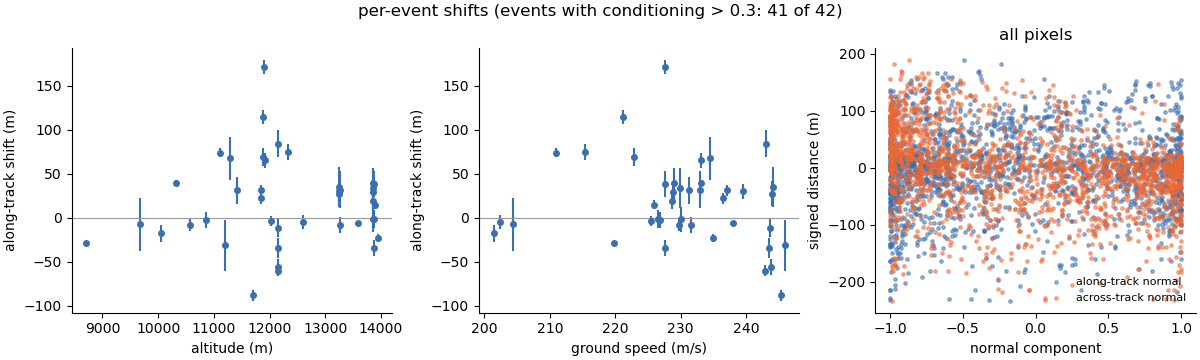

In [32]:
if frames:
    residuals = shoreline.body_frame_residuals(frames)
    display(shoreline.body_frame_shift(residuals, by='campaign').round(2))
    per_event = shoreline.body_frame_shift(residuals, by='event_id').join(
        events.set_index('event_id')[['flight', 'alt', 'gs', 'hdg', 'crossing_angle']])
    display(per_event.round(2))

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), layout='constrained')
    ok = per_event['conditioning'] > 0.3
    for ax, xvar, label in zip(axes, ['alt', 'gs'], ['altitude (m)', 'ground speed (m/s)']):
        ax.errorbar(per_event.loc[ok, xvar], per_event.loc[ok, 'along'], per_event.loc[ok, 'along_err'],
                    fmt='o', color='#3a6fb0', ms=4)
        ax.axhline(0, color='0.6', lw=0.8)
        ax.set(xlabel=label, ylabel='along-track shift (m)')
    ax = axes[2]
    ax.scatter(residuals['n_along'], residuals['d'], s=6, alpha=0.5, label='along-track normal', color='#3a6fb0')
    ax.scatter(residuals['n_across'], residuals['d'], s=6, alpha=0.5, label='across-track normal', color='#eb6834')
    ax.set(xlabel='normal component', ylabel='signed distance (m)', title='all pixels')
    ax.legend(frameon=False, fontsize=8)
    fig.suptitle(f'per-event shifts (events with conditioning > 0.3: {ok.sum()} of {len(ok)})');

In [33]:
MODELS = {
    'pitch': ('pitch',),
    'dt': ('dt',),
    'roll + pitch': ('roll', 'pitch'),
    'roll + dt': ('roll', 'dt'),
    'roll + pitch + yaw': ('roll', 'pitch', 'yaw'),
    'roll + pitch + yaw + dt': ('roll', 'pitch', 'yaw', 'dt'),
}
results, rows = {}, []
for c, fr in by_campaign.items():
    n_events = len({f.event_id for f in fr})
    before = np.concatenate([f.distances() for f in fr])
    rows.append(dict(campaign=c, model='none', median=np.median(before), rms=np.sqrt(np.mean(before ** 2)),
                     p95=np.percentile(before, 95)))
    for name, params in MODELS.items():
        if len(params) >= n_events:
            continue  # not enough independent coasts yet
        result = shoreline.fit(fr, params=params)
        results[c, name] = result
        after = result.summary().loc['after']
        corr = result.corr.abs().to_numpy() if result.corr is not None else np.ones((1, 1))
        max_corr = (corr - np.eye(len(corr))).max() if len(corr) > 1 else 0.0
        rows.append(dict(campaign=c, model=name, median=after['median'], rms=after['rms'], p95=after['p95'],
                         max_corr=max_corr,
                         **{k: f'{v:+.3f} ± {result.std[k]:.3f}' for k, v in result.correction.items()}))
fit_table = pd.DataFrame(rows).set_index(['campaign', 'model']) if rows else pd.DataFrame()
fit_table.round(1)

median   rms    p95  max_corr           pitch              dt            roll             yaw
campaign  model                                                                                                                 
HALO-AC3  none                       60.3  79.9  147.3       NaN             NaN             NaN             NaN             NaN
          pitch                      60.5  79.9  146.9       0.0  +0.005 ± 0.039             NaN             NaN             NaN
          dt                         59.1  79.7  153.1       0.0             NaN  +0.093 ± 0.022             NaN             NaN
          roll + pitch               43.3  68.4  145.3       0.1  +0.025 ± 0.026             NaN  -0.343 ± 0.021             NaN
          roll + dt                  41.9  67.9  136.7       0.1             NaN  +0.075 ± 0.016  -0.336 ± 0.020             NaN
          roll + pitch + yaw         43.5  68.1  143.2       0.2  +0.028 ± 0.026             NaN  -0.341 ± 0.021  -0.145 ± 0.118
          roll + pitch + yaw + dt    40.9  62.6  119.7       0.8  -0.403 ± 0.037  +0.328 ± 0.022  -0.351 ± 0.020  -0.073 ± 0.107
PERCUSION none                       17.3  50.0  118.7       NaN             NaN             NaN             NaN             NaN
          pitch                      17.2  49.9  119.0       0.0  -0.009 ± 0.007             NaN             NaN             NaN
          dt                         17.4  49.8  117.3       0.0             NaN  -0.016 ± 0.007             NaN             NaN
          roll + pitch               16.6  49.8  113.5       0.0  -0.003 ± 0.007             NaN  -0.038 ± 0.007             NaN
          roll + dt                  16.7  49.8  112.8       0.0             NaN  -0.008 ± 0.007  -0.037 ± 0.007             NaN
          roll + pitch + yaw         16.2  49.9  115.8       0.3  +0.002 ± 0.007             NaN  -0.032 ± 0.007  -0.081 ± 0.036
          roll + pitch + yaw + dt    15.9  49.1  110.9       1.0  +0.397 ± 0.059  -0.400 ± 0.060  -0.024 ± 0.007  -0.101 ± 0.035

### Held-out check

Each flight is left out in turn, the model is fitted to the others, and the left-out flight's pixels are measured with that fit. The spread of the parameters gives honest uncertainties: pixels of one frame are not independent, so the errors in the table above are too small. Choose `MODEL` from the table above.

In [34]:
MODEL = 'roll + pitch + yaw + dt'
for c, fr in by_campaign.items():
    flights_c = {f.flight for f in fr}
    if len(flights_c) < 3 or len(MODELS[MODEL]) >= len({f.event_id for f in fr}):
        print(f'{c}: needs labelled events in at least 3 flights for this check ({len(flights_c)} so far)')
        continue
    held_out, jk_std = shoreline.jackknife(fr, by='flight', params=MODELS[MODEL])
    print(f'{c}, {MODEL}: held-out median {held_out["median"].median():.1f} m; jackknife standard errors:')
    display(jk_std.round(3).to_frame('std').T)
    display(held_out.round(3))

HALO-AC3, roll + pitch + yaw + dt: held-out median 42.7 m; jackknife standard errors:


,roll,pitch,yaw,dt
std,0.04,0.342,0.275,0.062


,roll,pitch,yaw,dt,median,rms
left_out,,,,,,
RF03,-0.351,-0.401,-0.074,0.328,34.473,44.525
RF05,-0.350,-0.404,-0.072,0.328,23.888,29.501
RF06,-0.360,-0.379,-0.053,0.311,22.957,42.222
RF07,-0.342,-0.415,-0.004,0.325,80.767,80.471
RF09,-0.379,-0.530,0.126,0.341,72.441,83.201
RF11,-0.323,-0.125,-0.002,0.263,87.090,106.777
RF13,-0.355,-0.357,-0.108,0.315,14.264,26.677
RF14,-0.348,-0.414,-0.069,0.328,9.939,18.834
RF15,-0.355,-0.369,-0.060,0.333,50.932,50.418


PERCUSION, roll + pitch + yaw + dt: held-out median 23.7 m; jackknife standard errors:


,roll,pitch,yaw,dt
std,0.024,0.287,0.051,0.328


,roll,pitch,yaw,dt,median,rms
left_out,,,,,,
ECVal_RF01,-0.003,0.351,-0.048,-0.384,23.723,42.629
ECVal_RF03,-0.038,0.073,-0.127,-0.025,24.235,61.623
ECVal_RF05,-0.029,0.478,-0.094,-0.480,26.653,32.336
ECVal_RF06,-0.034,0.348,-0.091,-0.362,8.984,17.381
RF01,-0.024,0.449,-0.100,-0.454,18.258,36.432


### Result

Residuals per event before and after the chosen fit, the new offset angles for `velox_tools/data/georef_paulr/velox_mounttree.yaml`, and the correction applied in the labeller above.

,pixels,frames,median,rms,p95
before,1159.0,25.0,60.3,79.9,147.3
after,1159.0,25.0,40.9,62.6,119.7


HALO-AC3: time offset +0.328 s; Offset-Angles:
    Channel1: Offset-Angles: {'offset_roll': -0.121, 'offset_pitch': -3.183, 'offset_yaw': -0.063}
    Channel2: Offset-Angles: {'offset_roll': -0.051, 'offset_pitch': -3.153, 'offset_yaw': -0.063}
    Channel3: Offset-Angles: {'offset_roll': 0.159, 'offset_pitch': -3.123, 'offset_yaw': -0.063}
    Channel5: Offset-Angles: {'offset_roll': -0.061, 'offset_pitch': -3.353, 'offset_yaw': -0.063}
    Channel6: Offset-Angles: {'offset_roll': 0.219, 'offset_pitch': -2.873, 'offset_yaw': -0.063}


,pixels,frames,median,rms,p95
before,759.0,18.0,17.3,50.0,118.7
after,759.0,18.0,15.9,49.1,110.9


PERCUSION: time offset -0.400 s; Offset-Angles:
    Channel1: Offset-Angles: {'offset_roll': -0.184, 'offset_pitch': -2.863, 'offset_yaw': 0.049}
    Channel2: Offset-Angles: {'offset_roll': -0.114, 'offset_pitch': -2.833, 'offset_yaw': 0.059}
    Channel3: Offset-Angles: {'offset_roll': 0.096, 'offset_pitch': -2.803, 'offset_yaw': 0.059}
    Channel5: Offset-Angles: {'offset_roll': -0.124, 'offset_pitch': -3.033, 'offset_yaw': 0.059}
    Channel6: Offset-Angles: {'offset_roll': 0.156, 'offset_pitch': -2.553, 'offset_yaw': 0.049}


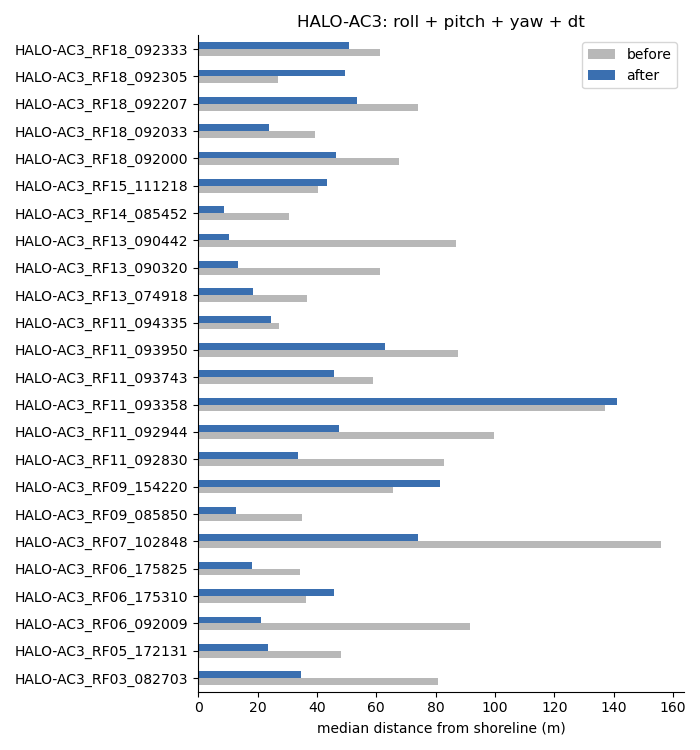

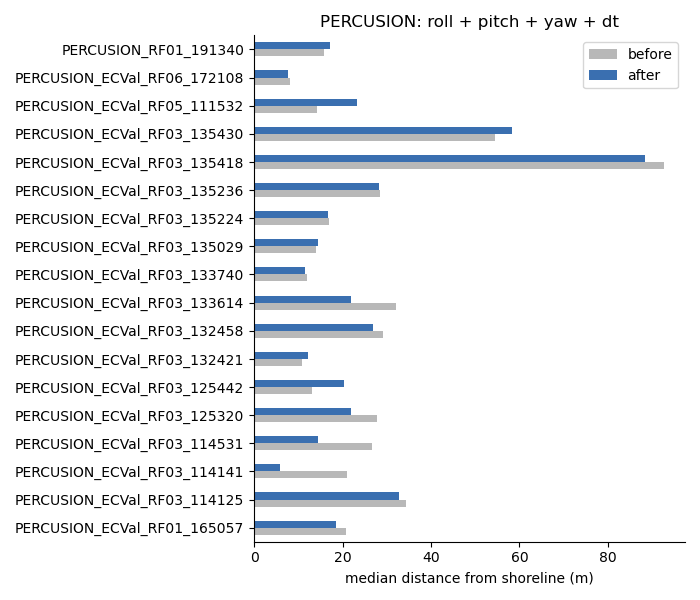

In [35]:
for c in by_campaign:
    result = results.get((c, MODEL))
    if result is None:
        continue
    display(result.summary().round(1))
    per_event = pd.concat({'before': result.before.groupby('event_id')['distance'].median(),
                           'after': result.after.groupby('event_id')['distance'].median()}, axis=1)
    ax = per_event.plot.barh(figsize=(7, 0.25 * len(per_event) + 1.5), color=['#b8b8b8', '#3a6fb0'])
    ax.set(xlabel='median distance from shoreline (m)', ylabel='', title=f'{c}: {MODEL}')
    ax.figure.tight_layout()
    print(f'{c}: time offset {result.correction.get("dt", 0):+.3f} s; Offset-Angles:')
    for channel, angles in result.offset_angles(c).items():
        print(f'    {channel}: Offset-Angles: {angles}')
    labeler.set_correction(result.correction)